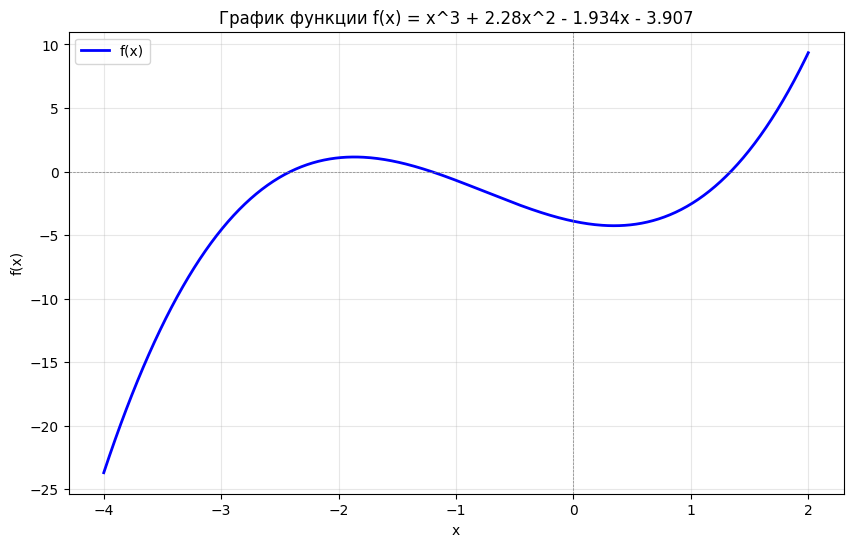


Поиск интервалов, содержащих корни:
Корень на интервале [-2.414, -2.408]
Корень на интервале [-1.213, -1.207]
Корень на интервале [1.339, 1.345]
Корень #1 на интервале [-2.414, -2.408]
f
[Метод половинного деления]
Корень: -2.409159, f(-2.409159) = 2.67e-03
Итераций: 2
+---+----------+----------+----------+----------+-----------+
| № |    a     |    b     |    c     |   f(c)   | |b - a|/2 |
+---+----------+----------+----------+----------+-----------+
| 1 | -2.41441 | -2.40841 | -2.41141 | -0.00748 |  0.00300  |
| 2 | -2.41141 | -2.40841 | -2.40991 | -0.00071 |  0.00150  |
+---+----------+----------+----------+----------+-----------+

[Метод хорд]
Корень: -2.409753, f(-2.409753) = -4.58e-08
Итераций: 2

[Метод простых итераций]
Корень: -2.409753, f(-2.409753) = -4.51e-11
Итераций: 2

[Метод простых итераций]
Корень: -2.411144, f(-2.411144) = -6.27e-03
Итераций: 1

Проверка (scipy.optimize.root_scalar)
Корень #2 на интервале [-1.213, -1.207]
f
[Метод половинного деления]
Корень: -1.209

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar, fsolve, newton
from scipy.integrate import quad, odeint
from prettytable import PrettyTable
import sympy as sp
from sympy.abc import epsilon


#Задание 1
#Методы решение нелинейного уравнения: f(x) = x^3 + 2.28x^2 - 1.934x - 3.907
#Интервал: [-4;2]

def f(x):
    return x**3 + 2.28*x**2 - 1.934*x - 3.907

def f_prime(x):
    return 3*x**2 + 2.28*2*x - 1.934

x_plot = np.linspace(-4, 2, 500)
y_plot = f(x_plot)

plt.figure(figsize=(10,6))
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('График функции f(x) = x^3 + 2.28x^2 - 1.934x - 3.907')
plt.grid(True, alpha = 0.3)
plt.legend()
plt.show()

print("\nПоиск интервалов, содержащих корни:")
x_search = np.linspace(-4, 2, 1000)
y_search = f(x_search)
sign_changes = np.where(np.diff(np.sign(y_search)))[0]

intervals = []
for idx in sign_changes:
    a_int, b_int = x_search[idx], x_search[idx+1]
    intervals.append((a_int, b_int))
    print(f"Корень на интервале [{a_int:.3f}, {b_int:.3f}]")

epsilon = 0.001

def bisection_method(f, a, b, eps):
    iterations = []
    if f(a) * f(b) > 0:
        return None, iterations

    n = 0
    while (b - a) / 2 > eps:
        c = (a + b) / 2
        iterations.append([n+1, a, b, c, f(c), abs(b-a)/2])

        if f(c) == 0:
            break
        elif f(a) * f(c) < 0:
            b = c
        else:
            a = c
        n += 1
        if n > 1000:
            break
    return (a + b) / 2, iterations

def secant_method(f, a, b, eps):
    iterations = []
    x_prev, x_curr= a, b
    n = 0

    while abs(x_curr - x_prev) > eps and n < 1000:
        if f(x_curr) - f(x_prev) == 0:
            break
        x_next = x_curr - f(x_curr) * (x_curr - x_prev) / (f(x_curr) - f(x_prev))
        iterations.append([n+1,x_prev, x_curr, x_next, f(x_next), abs(x_curr - x_prev)])
        x_prev, x_curr = x_curr, x_next
        n += 1
    return x_curr, iterations

def newton_method(f, f_prime, x0, eps):
    iterations = []
    x = x0
    n = 0

    while True:
        f_val = f(x)
        f_prime_val = f_prime(x)
        if abs(f_prime_val) < 1e-10:
            break

        x_new = x - f_val / f_prime_val
        iterations.append([n+1, x, f_val, f_prime_val, x_new, abs(x_new - x)])

        if abs(x_new - x) < eps:
            break
        x = x_new
        n += 1
        if n > 1000:
            break
    return x_new, iterations

def fixed_point_method(f, x0, eps, max_iter = 1000):
    x_vals = np.linspace(-4, 2, 100)
    f_prime_vals = np.abs(f_prime(x_vals))
    max_fp = np.max(f_prime_vals)
    lambda_val = 1 / (max_fp + 0.1) if max_fp > 0 else 1

    def F(x):
        return x - lambda_val * f(x)

    iterations = []
    x = x0
    n = 0

    while n < max_iter:
        x_new = F(x)
        iterations.append([n+1, x, x_new, f(x_new), abs(x_new - x)])

        if abs(x_new - x) < eps:
            break
        x = x_new
        n += 1

    return x_new, iterations

for i, (a_int, b_int) in enumerate(intervals, 1):
    print(f"Корень #{i} на интервале [{a_int:.3f}, {b_int:.3f}]")

    root_bis, iter_bis = bisection_method(f, a_int, b_int, epsilon)
    if root_bis is not None:
        print("f\n[Метод половинного деления]")
        print(f"Корень: {root_bis:.6f}, f({root_bis:.6f}) = {f(root_bis):.2e}")
        print(f"Итераций: {len(iter_bis)}")

        table = PrettyTable(['№', 'a', 'b', 'c', 'f(c)', '|b - a|/2'])
        for row in iter_bis[:10]:
            table.add_row([f"{r:.5f}" if isinstance(r, float) else r for r in row])
        print(table)

        root_sec, iter_sec = secant_method(f, a_int, b_int, epsilon)
        if root_sec is not None:
            print(f"\n[Метод хорд]")
            print(f"Корень: {root_sec:.6f}, f({root_sec:.6f}) = {f(root_sec):.2e}")
            print(f"Итераций: {len(iter_sec)}")

        x0_newton = (a_int + b_int) / 2
        root_newt, iter_newt = newton_method(f, f_prime, x0_newton, epsilon)
        print(f"\n[Метод простых итераций]")
        print(f"Корень: {root_newt:.6f}, f({root_newt:.6f}) = {f(root_newt):.2e}")
        print(f"Итераций: {len(iter_newt)}")

        root_fix, iter_fix = fixed_point_method(f, x0_newton, epsilon)
        print(f"\n[Метод простых итераций]")
        print(f"Корень: {root_fix:.6f}, f({root_fix:.6f}) = {f(root_fix):.2e}")
        print(f"Итераций: {len(iter_fix)}")

        try:
            root_scipy = root_scalar(f, bracket = [a_int, b_int], method = 'brentq', xtol = epsilon)
            print(f"\nПроверка (scipy.optimize.root_scalar)")
            print(f"Корень: {root_scipy:.6f}")
        except:
            pass



f_1(x,y) = y + sin(x-1) - 0.1 = 0
f_2(x,y) = x - sin(y+1) - 0.8 = 0


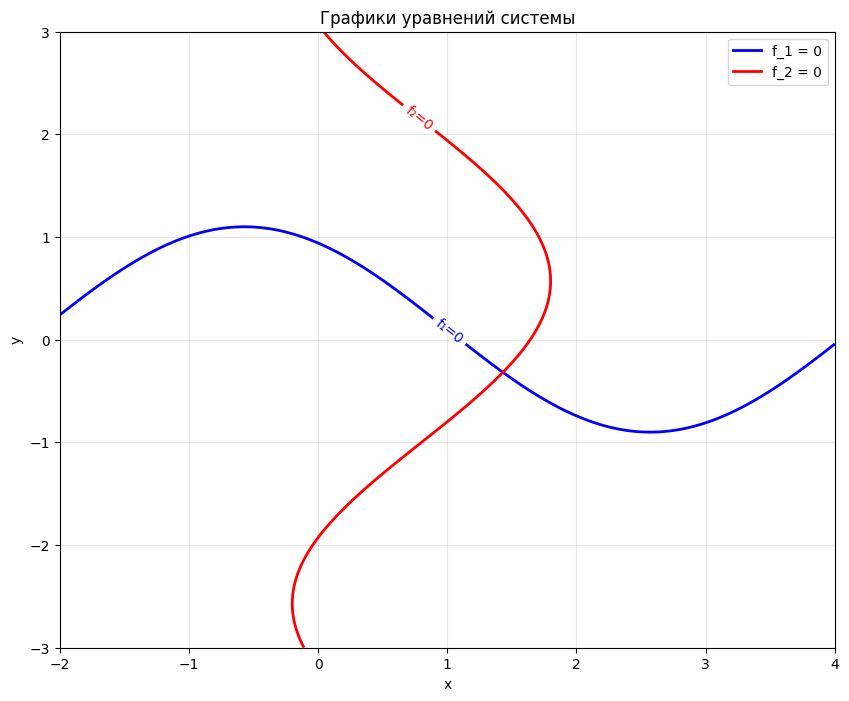


Начальное приближение: x0 = 1.0, y0 = 0.5

Решение системы:
x = 1.430717
y = -0.317523
f_1(x,y) = -2.04e-09
f_2(x,y) = 2.55e-09
Итераций: 4

Таблица итераций
+---+----------+-----------+-----------+-----------+-----------+
| № |    x     |     y     |    f_1    |    f_2    | ||delta|| |
+---+----------+-----------+-----------+-----------+-----------+
| 1 | 1.000000 |  0.500000 |  4.00e-01 | -7.97e-01 |  1.33e+00 |
| 2 | 1.718384 | -0.618384 | -6.02e-02 |  5.46e-01 |  4.00e-01 |
| 3 | 1.429883 | -0.340965 | -2.42e-02 |  1.75e-02 |  2.34e-02 |
| 4 | 1.430816 | -0.317613 | -1.82e-07 |  1.69e-04 |  1.34e-04 |
+---+----------+-----------+-----------+-----------+-----------+

[Проверка (scipy.optimize.fsolve)]
x = 1.430717, y = -0.317523


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import root_scalar, fsolve, newton
from scipy.integrate import quad, odeint
from prettytable import PrettyTable
import sympy as sp
from sympy.abc import epsilon

# Задание 2
# Система нелинейных уравнений методом Ньютона
# { sin(x-1) + y = 0.1
# { x - sin(y+1) = 0.8

print("f_1(x,y) = y + sin(x-1) - 0.1 = 0")
print("f_2(x,y) = x - sin(y+1) - 0.8 = 0")

def f1(x, y):
    return np.sin(x - 1) + y - 0.1

def f2(x, y):
    return -np.sin(y + 1) + x - 0.8

def jacobian(x, y):
    J = np.array([
        [np.cos(x - 1), 1],
        [1, - np.cos(y + 1)]
    ])
    return J

x_grid = np.linspace(-2, 4, 400)
y_grid = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x_grid, y_grid)

F1 = np.sin(X - 1) + Y - 0.1
F2 = X - np.sin(Y + 1) - 0.8

plt.figure(figsize=(10, 8))

contour1 = plt.contour(X, Y, F1, levels=[0], colors='blue', linewidths=2)
contour2 = plt.contour(X, Y, F2, levels=[0], colors='red', linewidths=2)

plt.clabel(contour1, inline=True, fontsize=10, fmt='f_1=0')
plt.clabel(contour2, inline=True, fontsize=10, fmt='f_2=0')

legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='f_1 = 0'),
    Line2D([0], [0], color='red', lw=2, label='f_2 = 0')
]

plt.xlabel('x')
plt.ylabel('y')
plt.title('Графики уравнений системы')
plt.grid(True, alpha=0.3)
plt.legend(handles=legend_elements)
plt.show()

x0, y0 = 1.0, 0.5
print(f"\nНачальное приближение: x0 = {x0}, y0 = {y0}")
def newton_system(f1, f2, jacobian, x0, y0, eps, max_iter = 50):
    x, y = x0, y0
    iterations = []

    for n in range(max_iter):
        F = np.array([f1(x,y), f2(x,y)])
        J = jacobian(x, y)

        try:
            delta = np.linalg.solve(J, -F)
        except np.linalg.LinAlgError:
            print("Матрица Якоби вырождена!")
            break

        x_new = x + delta[0]
        y_new = y + delta[1]

        error = np.sqrt((x_new - x)**2 + (y_new - y)**2)
        iterations.append([n+1, x, y, f1(x,y), f2(x,y), error])

        if error < eps:
            break

        x, y = x_new, y_new

    return x_new, y_new, iterations

x_sol, y_sol, iter_sys = newton_system(f1, f2, jacobian, x0, y0, 0.001)

print(f"\nРешение системы:")
print(f"x = {x_sol:.6f}")
print(f"y = {y_sol:.6f}")
print(f"f_1(x,y) = {f1(x_sol,y_sol):.2e}")
print(f"f_2(x,y) = {f2(x_sol,y_sol):.2e}")
print(f"Итераций: {len(iter_sys)}")

print("\nТаблица итераций")
table_sys = PrettyTable(["№", "x", "y", "f_1", "f_2", "||delta||"])
for row in iter_sys:
    table_sys.add_row([row[0],f"{row[1]:.6f}", f"{row[2]:.6f}", f"{row[3]:.2e}", f"{row[4]:.2e}",f"{row[5]:.2e}"])

print(table_sys)

try:
    def system(vars):
        x, y = vars
        return [f1(x,y), f2(x,y)]
    sol_scipy = fsolve(system, [x0, y0], full_output=True)
    x_scipy, y_scipy = sol_scipy[0]
    print(f"\n[Проверка (scipy.optimize.fsolve)]")
    print(f"x = {x_scipy:.6f}, y = {y_scipy:.6f}")
except Exception as e:
    print(f"Ошибка при проверке: {e}")


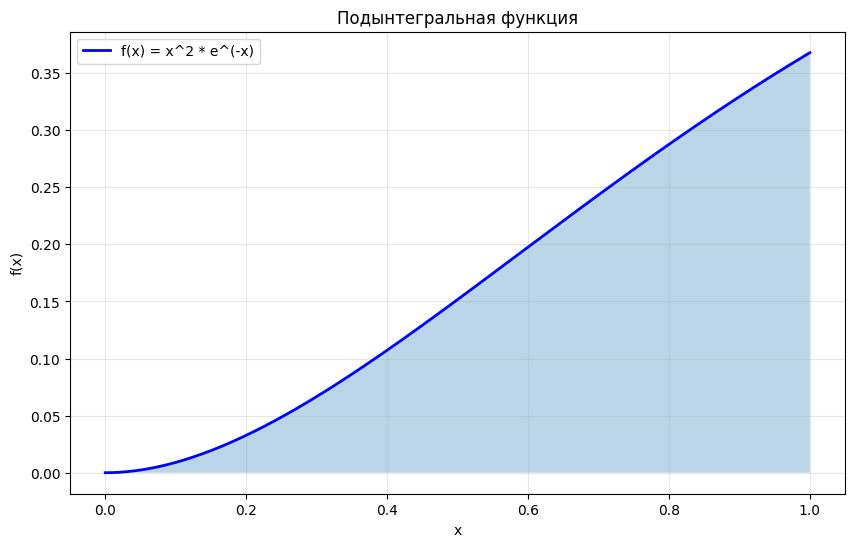

M = max|f''(x)| = 2.000000
Теоретический шаг: h < 0.077460
Число разбиений кратно 4: n = 16
Фактический шан: h = 0.062500
Проверка: |b-a| * h^2 * M/12 = 6.51e-04 < 0.001
I(h) = 0.16072243 (n = 16)
I(2h) = 0.16107990 (n = 8)
Оценка погрешности (Рунге): delta ~= 1.19e-04
I(h) = 0.16060327 (n = 16)
I(2h) = 0.16061039 (n = 8)
Оценка погрешности (Рунге): delta ~= 4.75e-07
Точное значение (scipy.quad): 0.16060279 +- 1.78e-15
Точное значение (аналитически): 0.16060279
Первообразная: (-x**2 - 2*x - 2)*exp(-x)
+---------------+------------+-------------+---------------+
|     Метод     |  Значение  | Погрешность | Отн. погр (%) |
+---------------+------------+-------------+---------------+
|  Трапеции (h) | 0.16072243 |   1.20e-04  |     0.0745    |
| Трапеции (2h) | 0.16107990 |   4.77e-04  |     0.2971    |
|  Симпсон (h)  | 0.16060327 |   4.77e-07  |     0.0003    |
|  Симпсон (2h) | 0.16061039 |   7.60e-06  |     0.0047    |
+---------------+------------+-------------+---------------+


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import root_scalar, fsolve, newton
from scipy.integrate import quad, odeint
from prettytable import PrettyTable
import sympy as sp
from sympy.abc import epsilon

# Задание 3
# Вычисление интеграла
# f(x) = x^2 * e^(-x)

def f_int(x):
    return x ** 2 * np.exp(-x)

def f_int_second(x):
    return np.exp(-x) * (x ** 2 - 4*x + 2)

a, b = 0, 1
epsilon_int = 0.001

x_int = np.linspace(a, b, 200)
y_int = f_int(x_int)

plt.figure(figsize=(10, 6))
plt.plot(x_int, y_int, 'b-', linewidth=2, label='f(x) = x^2 * e^(-x)')
plt.fill_between(x_int, y_int, alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Подынтегральная функция')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

x_second = np.linspace(a, b, 1000)
M = np.max(np.abs(f_int_second(x_second)))
print(f"M = max|f''(x)| = {M:.6f}")

h_theoretical = np.sqrt(12 * epsilon_int / (abs(b - a) * M))
print(f"Теоретический шаг: h < {h_theoretical:.6f}")

n_min = int(np.ceil((b -a ) / h_theoretical))
n = ((n_min + 3) // 4) * 4
h = (b - a) / n

print(f"Число разбиений кратно 4: n = {n}")
print(f"Фактический шан: h = {h:.6f}")
print(f"Проверка: |b-a| * h^2 * M/12 = {abs(b-a) * h**2 * M/12:.2e} < {epsilon_int}")

def trapezoidal_rule(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = f(x)
    return h * (y[0]/2 + np.sum(y[1:-1]) + y[-1]/2)

I_trap_h = trapezoidal_rule(f_int, a, b, n)
I_trap_2h = trapezoidal_rule(f_int, a, b, n//2)

print(f"I(h) = {I_trap_h:.8f} (n = {n})")
print(f"I(2h) = {I_trap_2h:.8f} (n = {n//2})")

error_trap = abs(I_trap_h - I_trap_2h) / 3
print(f"Оценка погрешности (Рунге): delta ~= {error_trap:.2e}")

def simpson_rule(f, a, b, n):
    if n % 2 == 1:
        n+= 1
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = f(x)

    return h/3 * (y[0] + y[-1] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-1:2]))

I_simp_h = simpson_rule(f_int, a, b, n)
I_simp_2h = simpson_rule(f_int, a, b, n//2)

print(f"I(h) = {I_simp_h:.8f} (n = {n})")
print(f"I(2h) = {I_simp_2h:.8f} (n = {n//2})")

error_simp = abs(I_simp_h - I_simp_2h) / 15
print(f"Оценка погрешности (Рунге): delta ~= {error_simp:.2e}")


I_exact_scipy, err_scipy = quad(f_int, a, b)
print(f"Точное значение (scipy.quad): {I_exact_scipy:.8f} +- {err_scipy:.2e}")

x_sym = sp.symbols('x')
f_sym = x_sym**2 * sp.exp(-x_sym)
I_exact_sym = sp.integrate(f_sym, (x_sym, a, b))
I_exact_val = float(I_exact_sym.evalf())
print(f"Точное значение (аналитически): {I_exact_val:.8f}")
print(f"Первообразная: {sp.integrate(f_sym, x_sym)}")

results = PrettyTable(['Метод', 'Значение', 'Погрешность', 'Отн. погр (%)'])
results.add_row(['Трапеции (h)', f"{I_trap_h:.8f}", f"{abs(I_trap_h - I_exact_val):.2e}", f"{abs(I_trap_h - I_exact_val)/I_exact_val*100:.4f}"])
results.add_row(['Трапеции (2h)', f"{I_trap_2h:.8f}", f"{abs(I_trap_2h - I_exact_val):.2e}", f"{abs(I_trap_2h - I_exact_val)/I_exact_val*100:.4f}"])
results.add_row(['Симпсон (h)', f"{I_simp_h:.8f}", f"{abs(I_simp_h - I_exact_val):.2e}", f"{abs(I_simp_h - I_exact_val)/I_exact_val*100:.4f}"])
results.add_row(['Симпсон (2h)', f"{I_simp_2h:.8f}", f"{abs(I_simp_2h - I_exact_val):.2e}", f"{abs(I_simp_2h - I_exact_val)/I_exact_val*100:.4f}"])
print(results)




Начальная оценка шага: h0 = 0.1000
Подобранный шан: h = 0.200000
Число шагов: n =10
Оценка погрешности: delta = 5.92e-06 < 0.0001

Таблица результатов (выборочно):
+--------+----------+----------+----------------------+
|   x    |   y(x)   | y_точное | |y_прибл - y_точное| |
+--------+----------+----------+----------------------+
| 0.0000 | 1.000000 | 1.000000 |       0.00e+00       |
| 0.2000 | 0.818741 | 0.818731 |       9.97e-06       |
| 0.4000 | 0.670332 | 0.670320 |       1.19e-05       |
| 0.6000 | 0.548823 | 0.548812 |       1.09e-05       |
| 0.8000 | 0.449338 | 0.449329 |       9.10e-06       |
| 1.0000 | 0.367887 | 0.367879 |       7.45e-06       |
| 1.2000 | 0.301200 | 0.301194 |       6.27e-06       |
| 1.4000 | 0.246603 | 0.246597 |       5.61e-06       |
| 1.6000 | 0.201902 | 0.201897 |       5.41e-06       |
| 1.8000 | 0.165304 | 0.165299 |       5.58e-06       |
| 2.0000 | 0.135341 | 0.135335 |       6.08e-06       |
+--------+----------+----------+--------------------

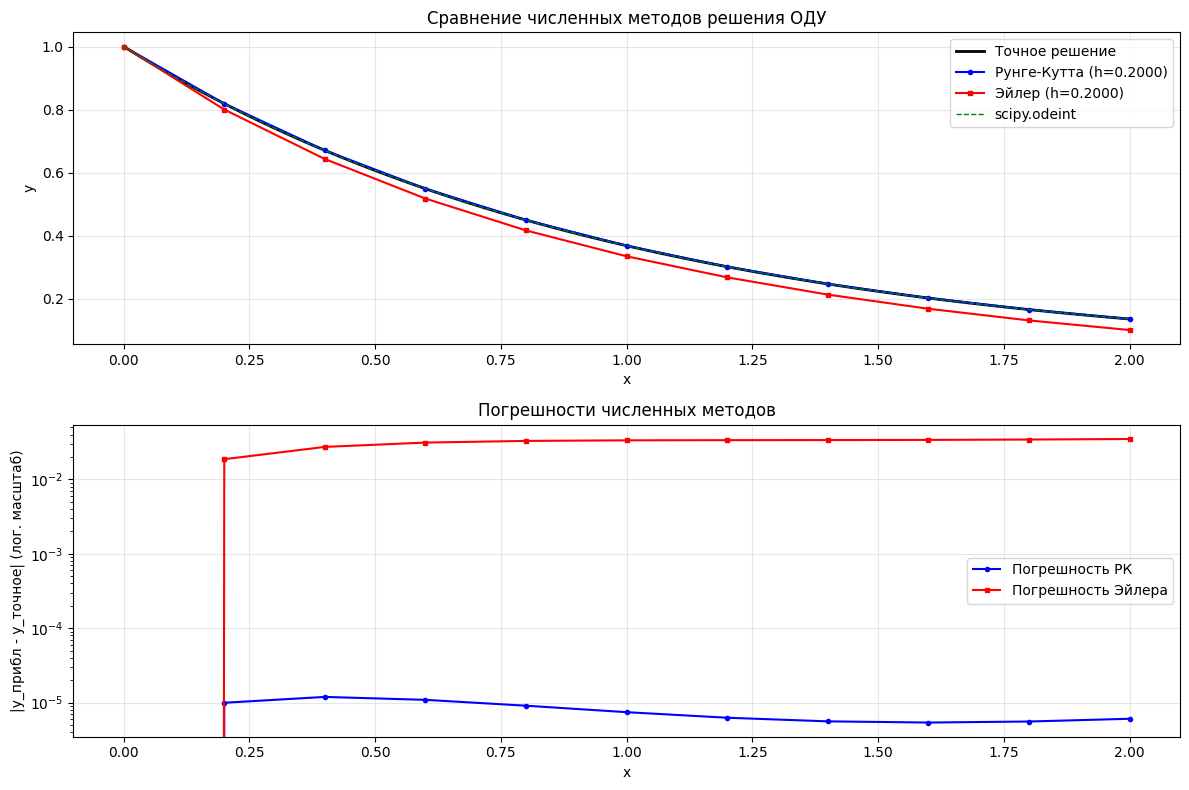

+--------------+------------+-------------+----------------+
|    Метод     |    y(2)    | Погрешность | Отн. погр. (%) |
+--------------+------------+-------------+----------------+
|    Точное    | 0.13533528 |      -      |       -        |
| Рунге-Кутта  | 0.13534136 |   6.08e-06  |     0.0045     |
|    Эйлер     | 0.10036374 |   3.50e-02  |    25.8407     |
| scipy.odeint | 0.13533526 |   2.16e-08  |     0.0000     |
+--------------+------------+-------------+----------------+

Максимальная погрешность на всём интервале:
  Метод Рунге-Кутта: 1.19e-05
  Метод Эйлера: 3.50e-02


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import root_scalar, fsolve, newton
from scipy.integrate import quad, odeint
from prettytable import PrettyTable
import sympy as sp
from sympy.abc import epsilon

# Задание 4
# Решить задачу Коши
# y' + xy = (x - 1)e^xy^2, y(0) = 1, a = 0, b = 2

def f_ode(x,y):
    return (x - 1) * np.exp(x) * y**2 - x*y

x_sym, y_sym = sp.symbols('x y')
ode_eq = sp.Eq(sp.diff(y_sym, x_sym) + x_sym*y_sym, (x_sym-1)*sp.exp(x_sym)*y_sym**2)

def exact_solution(x):
    def integrand(t):
        return (t - 1) * np.exp(t) * np.exp(-t**2/2)
    if np.isscalar(x):
        integral, _ = quad(integrand, 0, x)
        denominator = 1 - integral
        return np.exp(-x**2 / 2) / denominator if abs(denominator) > 1e-10 else np.inf
    else:
        result = []
        for xi in x:
            integral, _ = quad(integrand, 0, xi)
            denominator = 1 - integral
            result.append(np.exp(-xi**2 / 2) / denominator if abs(denominator) > 1e-10 else np.inf)
        return np.array(result)

def runge_kutta_4(f, x0, y0, h, n_steps):
    x = x0
    y = y0
    xs, ys = [x], [y]

    for _ in range(n_steps):
        k1 = f(x,y)
        k2 = f(x + h/2, y + h*k1/2)
        k3 = f(x + h/2, y + h*k2/2)
        k4 = f(x + h, y + h*k3)

        y = y + h/6 * (k1 + 2*k2 + 2*k3 + k4)
        x = x + h
        xs.append(x)
        ys.append(y)

    return np.array(xs), np.array(ys)

def euler_method(f, x0, y0, h, n_steps):
    x = x0
    y = y0
    xs, ys = [x], [y]

    for _ in range(n_steps):
        y = y + h * f(x, y)
        x = x + h
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

epsilon_ode = 1e-4
a_ode, b_ode = 0, 2
y0_ode = 1

h0 = epsilon_ode ** 0.25
print(f"Начальная оценка шага: h0 = {h0:.4f}")

def find_step_rk(f, x0, y0, b, eps, h_start):
    h = h_start

    while True:
        n = int((b - x0) / h)
        if n < 2:
            h /= 2
            continue

        x1, y1 = runge_kutta_4(f, x0, y0, h, n)

        n2 = n // 2
        if n2 < 1:
            h /= 2
            continue
        x2, y2 = runge_kutta_4(f, x0, y0, 2*h, n2)
        delta = abs(y1[-1] - y2[-1]) / 15
        if delta < eps:
            h_test = h * 2
            n_test = int((b - x0) / h_test)
            if n_test >= 2:
                x_test, y_test = runge_kutta_4(f, x0, y0, h_test, n_test)
                x_test2, y_test2 = runge_kutta_4(f, x0, y0, 2*h_test, n_test//2)
                delta_test = abs(y_test[-1] - y_test2[-1]) / 15
                if delta_test < eps:
                    h = h_test
                    continue
            return h, y1[-1], y2[-1], delta
        else:
            h /= 2
            if h < 1e-6:
                print("Достигнут минимальный шаг")
                return h, y1[-1], y2[-1], delta

h_final, y_h, y_2h, delta_final = find_step_rk(f_ode, a_ode, y0_ode, b_ode, epsilon_ode, h0)
n_final = int((b_ode - a_ode) / h_final)

print(f"Подобранный шан: h = {h_final:.6f}")
print(f"Число шагов: n ={n_final}")
print(f"Оценка погрешности: delta = {delta_final:.2e} < {epsilon_ode}")

x_rk, y_rk = runge_kutta_4(f_ode, a_ode, y0_ode, h_final, n_final)

print("\nТаблица результатов (выборочно):")
table_rk = PrettyTable(['x', 'y(x)', 'y_точное', '|y_прибл - y_точное|'])
for i in range(0, len(x_rk), max(1, len(x_rk)//10)):
    y_exact = exact_solution(x_rk[i])
    error = abs(y_rk[i] - y_exact)
    table_rk.add_row([f"{x_rk[i]:.4f}", f"{y_rk[i]:.6f}", f"{y_exact:.6f}", f"{error:.2e}"])
print(table_rk)

x_euler, y_euler = euler_method(f_ode, a_ode, y0_ode, h_final, n_final)

print("\nТаблица результатов (выборочно):")
table_euler = PrettyTable(['x', 'y(x)', 'y_точное', '|y_прибл - y_точное|'])
for i in range(0, len(x_euler), max(1, len(x_euler)//10)):
    y_exact = exact_solution(x_euler[i])
    error = abs(y_euler[i] - y_exact)
    table_euler.add_row([f"{x_euler[i]:.4f}", f"{y_euler[i]:.6f}", f"{y_exact:.6f}", f"{error:.2e}"])
print(table_euler)

def f_ode_for_odeint(y, x):
    return f_ode(x,y)

x_scipy = np.linspace(a_ode, b_ode, 100)
y_scipy = odeint(f_ode_for_odeint, y0_ode, x_scipy).flatten()

y_exact_plot = exact_solution(x_scipy)
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(x_scipy, y_exact_plot, 'k-', linewidth=2, label = 'Точное решение')
plt.plot(x_rk, y_rk, 'b-o', markersize=3, label = 'Рунге-Кутта (h=%.4f)' % h_final)
plt.plot(x_euler, y_euler, 'r-s', markersize=3, label = 'Эйлер (h=%.4f)' %h_final)
plt.plot(x_scipy, y_scipy, 'g--', linewidth=1, label = 'scipy.odeint')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение численных методов решения ОДУ')
plt.legend()
plt.grid(True, alpha = 0.3)

plt.subplot(2, 1, 2)
error_rk = np.abs(y_rk - exact_solution(x_rk))
error_euler = np.abs(y_euler - exact_solution(x_euler))
plt.semilogy(x_rk, error_rk, 'b-o', markersize=3, label='Погрешность РК')
plt.semilogy(x_euler, error_euler, 'r-s', markersize=3, label='Погрешность Эйлера')
plt.xlabel('x')
plt.ylabel('|y_прибл - y_точное| (лог. масштаб)')
plt.title('Погрешности численных методов')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

y_exact_end = exact_solution(b_ode)
y_rk_end = y_rk[-1]
y_euler_end = y_euler[-1]
y_scipy_end = y_scipy[-1]

results_ode = PrettyTable(['Метод', 'y(2)', 'Погрешность', 'Отн. погр. (%)'])
results_ode.add_row(['Точное', f"{y_exact_end:.8f}", '-', '-'])
results_ode.add_row(['Рунге-Кутта', f"{y_rk_end:.8f}",  f"{abs(y_rk_end - y_exact_end):.2e}",  f"{abs(y_rk_end - y_exact_end)/abs(y_exact_end)*100:.4f}"])
results_ode.add_row(['Эйлер', f"{y_euler_end:.8f}", f"{abs(y_euler_end - y_exact_end):.2e}", f"{abs(y_euler_end - y_exact_end)/abs(y_exact_end)*100:.4f}"])
results_ode.add_row(['scipy.odeint', f"{y_scipy_end:.8f}", f"{abs(y_scipy_end - y_exact_end):.2e}", f"{abs(y_scipy_end - y_exact_end)/abs(y_exact_end)*100:.4f}"])
print(results_ode)

max_error_rk = np.max(np.abs(y_rk - exact_solution(x_rk)))
max_error_euler = np.max(np.abs(y_euler - exact_solution(x_euler)))

print(f"\nМаксимальная погрешность на всём интервале:")
print(f"  Метод Рунге-Кутта: {max_error_rk:.2e}")
print(f"  Метод Эйлера: {max_error_euler:.2e}")
